In [ ]:
import pandas as pd
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import imblearn
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from xgboost import XGBClassifier

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 데이터 불러오기
train_df = pd.read_parquet('../data/Data/train_df_cleaned.parquet')

# 특성, 타겟 분리
feature_cols = [col for col in train_df.columns if col not in ["ID", "Segment"]]
X = train_df[feature_cols].copy()
y = train_df["Segment"].copy()

# 문자열 레이블 → 숫자 변환
y_encoded = y.map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4})

# A(0), B(1) 클래스만 필터링
ab_mask = y_encoded.isin([0, 1])
X_ab = X[ab_mask]
y_ab = y_encoded[ab_mask].astype(int).to_numpy()

# 클래스 가중치 계산
ab_classes = np.array([0, 1], dtype=int)
ab_weights = compute_class_weight(class_weight='balanced', classes=ab_classes, y=y_ab)
ab_class_weights = dict(zip(ab_classes, ab_weights))
w_ab = pd.Series(y_ab).map(ab_class_weights)

# XGBoost 이진 분류 학습
ab_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=700,
    tree_method='hist',
    device='cuda',
    random_state=42
)
ab_model.fit(X_ab, y_ab, sample_weight=w_ab, verbose=False)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=700, n_jobs=None,
              num_parallel_tree=None, ...)

<Figure size 1000x2000 with 0 Axes>

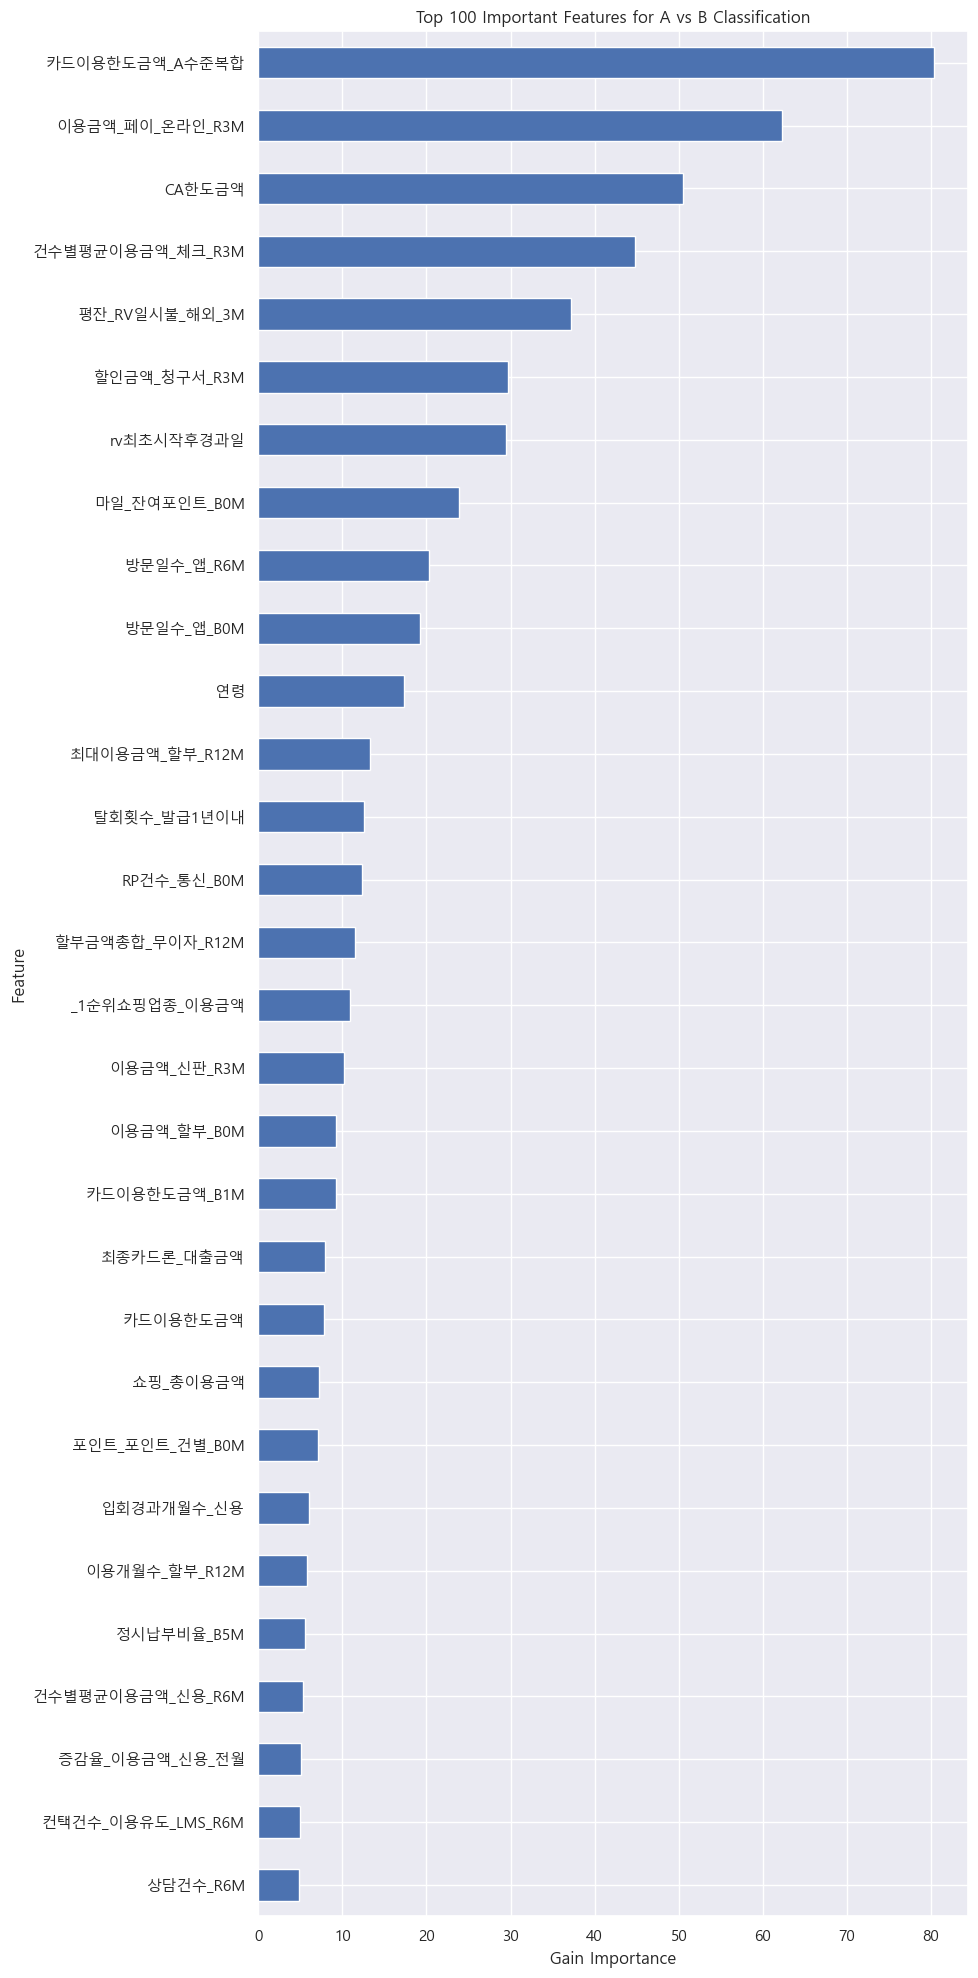

In [5]:
# 피처 중요도 가져오기 (gain 기준)
importance_dict = ab_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame.from_dict(importance_dict, orient='index', columns=['importance'])
importance_df.index.name = 'feature'
importance_df = importance_df.reset_index()

# 중요도 기준 상위 100개 -> 30개
top100 = importance_df.sort_values(by='importance', ascending=False).head(30)

# 시각화
plt.figure(figsize=(10, 20))
top100.sort_values(by='importance').plot(
    kind='barh', 
    x='feature', 
    y='importance', 
    legend=False,
    figsize=(10, 20)
)
plt.title('Top 100 Important Features for A vs B Classification')
plt.xlabel('Gain Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

c:\Users\COTTA\anaconda3\Lib\site-packages\xgboost\core.py:729: UserWarning: [11:24:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


              precision    recall  f1-score   support

           A       1.00      0.98      0.99       195
           B       0.88      1.00      0.94        29

    accuracy                           0.98       224
   macro avg       0.94      0.99      0.96       224
weighted avg       0.98      0.98      0.98       224



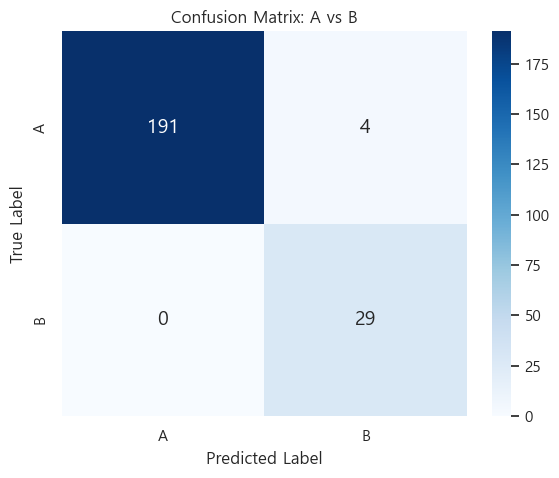

In [6]:
# 데이터 분리
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_ab, y_ab, w_ab, test_size=0.2, random_state=42, stratify=y_ab
)

# 모델 훈련
ab_model.fit(X_train, y_train, sample_weight=w_train, verbose=False)

# 예측 및 평가
y_pred = ab_model.predict(X_val)
print(classification_report(y_val, y_pred, target_names=['A', 'B']))

# Confusion matrix 계산
cm = confusion_matrix(y_val, y_pred)
labels = ['A', 'B']

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: A vs B')
plt.tight_layout()
plt.show()